## Data Exploration for Juggling Robot which is derived from the generate_data.py file

In [1]:
import time

import jax
import jax.numpy as jnp
import jax.nn as jnn
import jax.random as jr
from diffrax import backward_hermite_coefficients, CubicInterpolation
from jaxtyping import Array, PRNGKeyArray
from typing import Callable

import diffrax
import equinox as eqx

import optax

from functools import partial

import numpy as np
import matplotlib.pyplot as plt

In [195]:
# Load the data
data = np.load('juggle_data.npz')
ts = data['ts']       # shape: (T,)
us = data['us']       # shape: (N, T, DOF)
qs = data['qs']       # shape: (N, T, DOF)
qs_t = data['qs_t']   # shape: (N, T, DOF)
qs_tt = data['qs_tt'] # shape: (N, T, DOF)

print("ts shape:", ts.shape)
print("us shape:", us.shape)
print("qs shape:", qs.shape)

T_total = ts.shape[0]
T_cut = int(0.2 * T_total)

# 2. Truncate the time series
ts = ts[:T_cut]
us = us[:, :T_cut, :]
qs = qs[:, :T_cut, :]
qs_t = qs_t[:, :T_cut, :]
qs_tt = qs_tt[:, :T_cut, :]

print("ts shape:", ts.shape)
print("us shape:", us.shape)
print("qs shape:", qs.shape)



ts shape: (5001,)
us shape: (50, 5001, 4)
qs shape: (50, 5001, 4)
ts shape: (1000,)
us shape: (50, 1000, 4)
qs shape: (50, 1000, 4)


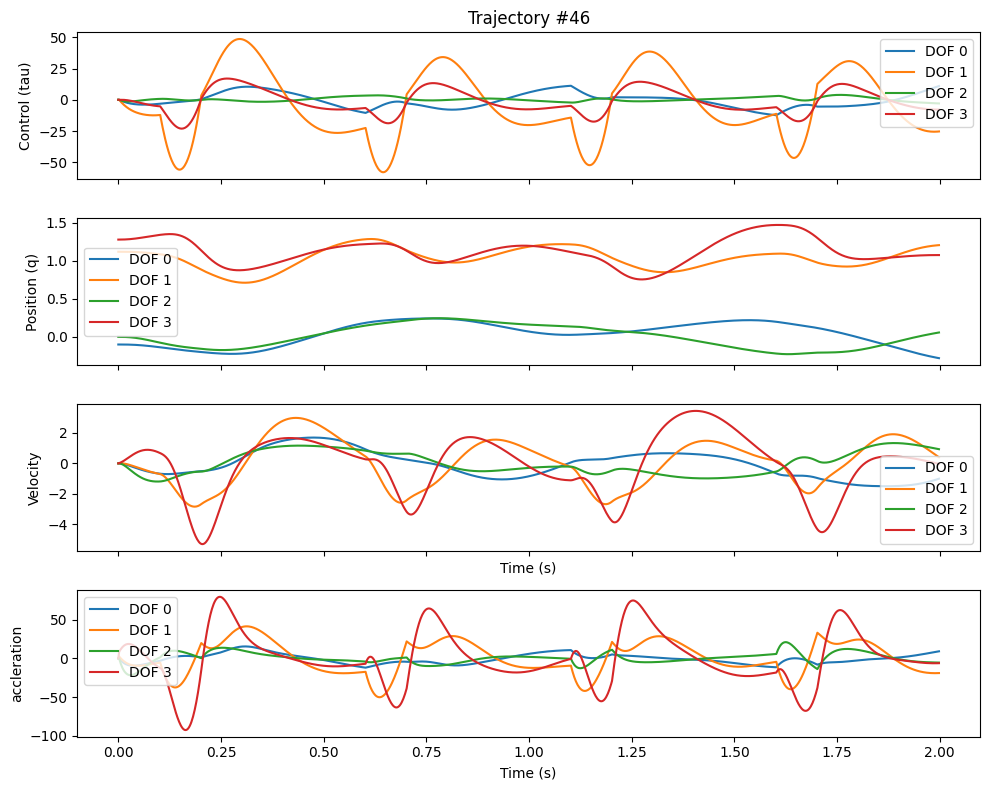

In [196]:
#Select one trajectory to visualize (e.g., the first)
i = 45 # index from 0 to N-1
time = ts
u = us[i]
q = qs[i]
dq = qs_t[i]
ddq = qs_tt[i]

# Plot control and joint angles
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axes[0].set_title(f"Trajectory #{i+1}")
axes[0].plot(time, u)
axes[0].set_ylabel("Control (tau)")
axes[0].legend([f"DOF {j}" for j in range(u.shape[1])])

axes[1].plot(time, q)
axes[1].set_ylabel("Position (q)")
axes[1].legend([f"DOF {j}" for j in range(q.shape[1])])

axes[2].plot(time, dq)
axes[2].set_ylabel("Velocity")
axes[2].set_xlabel("Time (s)")
axes[2].legend([f"DOF {j}" for j in range(dq.shape[1])])

axes[3].plot(time, ddq)
axes[3].set_ylabel("accleration")
axes[3].set_xlabel("Time (s)")
axes[3].legend([f"DOF {j}" for j in range(dq.shape[1])])


plt.tight_layout()
plt.show()

# Checking distribution of first and last position

In [197]:
N, T, DOF = qs.shape

# Summary stats of initial and final positions
initial_qs = qs[:, 0, :]
final_qs = qs[:, -1, :]

print("Initial positions stats:")
print("Mean:", np.mean(initial_qs, axis=0))
print("Min:", np.min(initial_qs, axis=0))
print("Max:", np.max(initial_qs, axis=0))

print("\nFinal positions stats:")
print("Mean:", np.mean(final_qs, axis=0))
print("Std:", np.std(final_qs, axis=0))
print("Min:", np.min(final_qs, axis=0))
print("Max:", np.max(final_qs, axis=0))

Initial positions stats:
Mean: [-0.1   1.12  0.    1.28]
Min: [-0.1   1.12  0.    1.28]
Max: [-0.1   1.12  0.    1.28]

Final positions stats:
Mean: [-0.07147762  1.14014074 -0.00639859  1.21249129]
Std: [0.12916838 0.12908141 0.10994359 0.09702126]
Min: [-0.40543078  0.85973365 -0.24008326  0.95468349]
Max: [0.19476654 1.3680604  0.20548793 1.37606505]


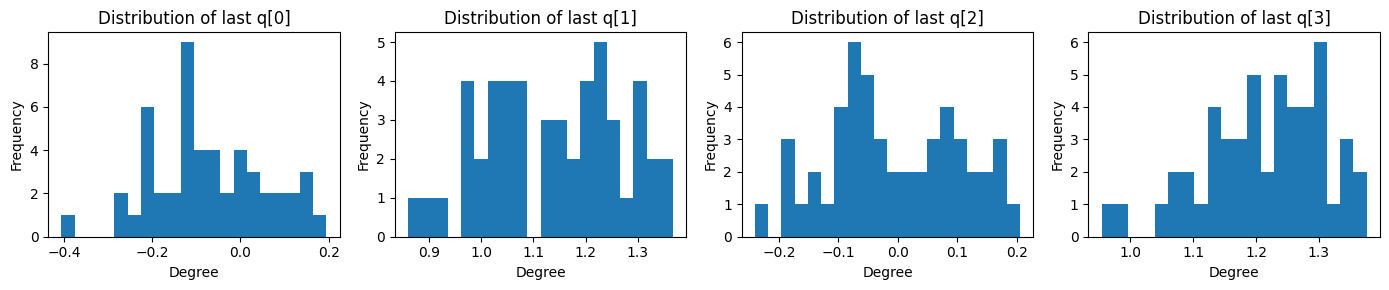

In [198]:
# Visualize distribution for each joint
DOF = 4
fig, axes = plt.subplots(1, DOF, figsize=(14, 3))

for i in range(DOF):
    axes[i].hist(final_qs[:, i], bins=20)
    axes[i].set_title(f"Distribution of last q[{i}]")
    axes[i].set_xlabel("Degree")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# checking the derivation of trajectories with each other

C:\Users\sormeabkenar\AppData\Local\Temp\ipykernel_14172\920640704.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


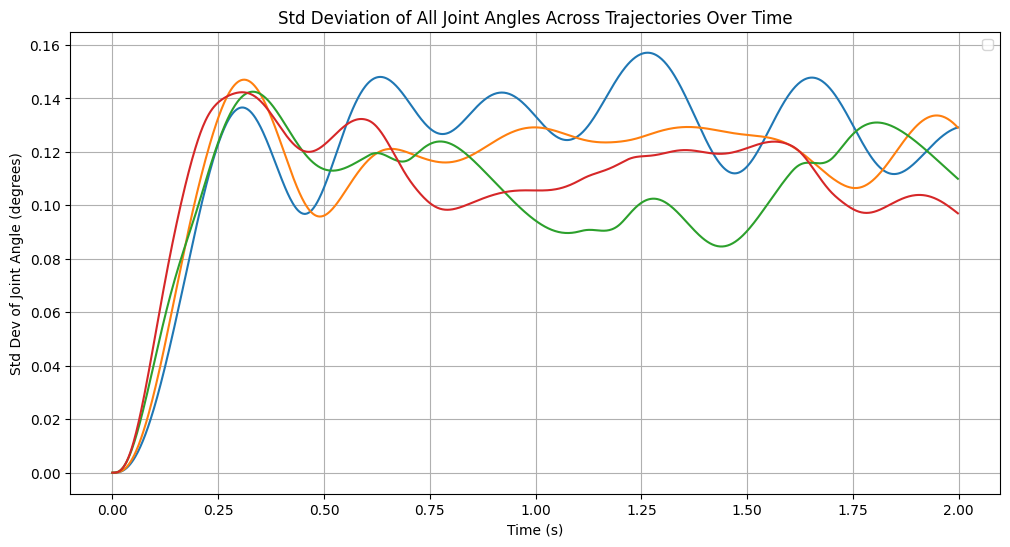

In [199]:
max_time = ts[-1]
time_points = np.arange(0, max_time + 1, 1)  # whole seconds

indices = [np.argmin(np.abs(ts - t)) for t in time_points]

plt.figure(figsize=(12, 6))

for joint_idx in range(qs.shape[2]):  # for all 4 joints
    plt.plot(ts, jnp.std(qs[...,joint_idx], axis=0))

plt.xlabel('Time (s)')
plt.ylabel('Std Dev of Joint Angle (degrees)')
plt.title('Std Deviation of All Joint Angles Across Trajectories Over Time')
plt.legend()
plt.grid()
plt.show()


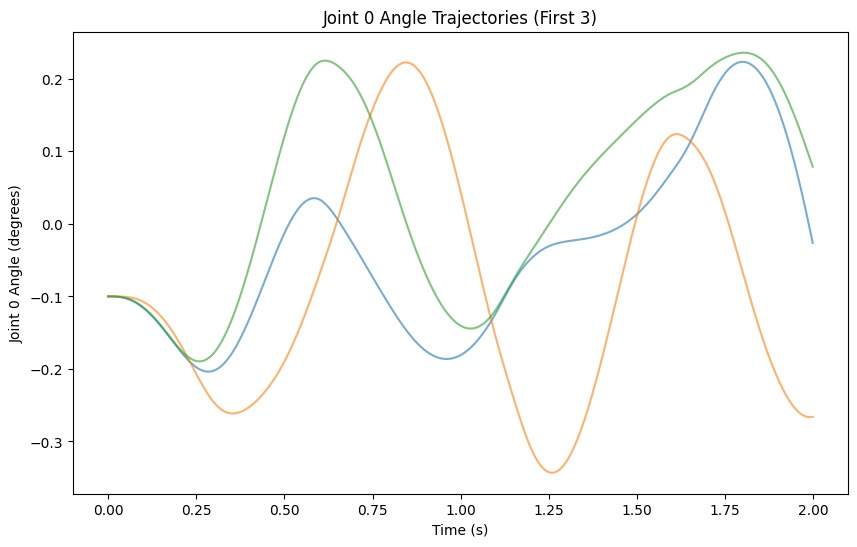

In [200]:
joint_idx = 0
plt.figure(figsize=(10,6))
for i in range(min(3, N)):  # Plot only first 3 trajectories
    plt.plot(ts, qs[i, :, joint_idx], alpha=0.6)
plt.xlabel('Time (s)')
plt.ylabel(f'Joint {joint_idx} Angle (degrees)')
plt.title(f'Joint {joint_idx} Angle Trajectories (First 3)')
plt.show()
